# New

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import h5py
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim.lr_scheduler import ReduceLROnPlateau

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

from google.colab import drive
drive.mount('/content/drive')
BASE_DIR = "/content/drive/MyDrive/data/"

Using device: cuda
Mounted at /content/drive


### Data Preprocessing

In [2]:
class H5Dataset(Dataset):
    """Dataset for regression task, adapted from baseline_clf.py"""
    def __init__(self, h5_path: str):
        self.h5f = h5py.File(h5_path, 'r')
        self.images = self.h5f['images']
        self.valid_indices = self._filter_nan_samples()
        self.n_samples = len(self.valid_indices)
        print(f"H5Dataset initialized: {h5_path}")
        print(f"Total samples: {len(self.images)}")
        print(f"Valid samples: {self.n_samples}")

    def _filter_nan_samples(self):
        """Filter samples with NaN in VV or VH bands"""
        valid_indices = []
        for idx in range(len(self.images)):
            img = self.images[idx].astype(np.float32)
            input_bands = img[1:3]  # VV, VH
            if not np.isnan(input_bands).any():
                valid_indices.append(idx)
        return valid_indices

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        actual_idx = self.valid_indices[idx]
        img = self.images[actual_idx].astype(np.float32).copy()

        # Input: VV, VH bands
        input_bands = img[1:3]  # VV, VH
        vv = torch.from_numpy(input_bands[0])  # [H, W]
        vh = torch.from_numpy(input_bands[1])  # [H, W]
        image = torch.stack([vv, vh], dim=0)   # [2, H, W]

        # Target: CHM (first channel)
        target = torch.from_numpy(img[0:1])  # [1, H, W]
        # Set invalid values (< 1.0) to NaN
        target[target < 1.0] = float('nan')

        return image, target

    def close(self):
        if hasattr(self, 'h5f'):
            self.h5f.close()

    def __del__(self):
        self.close()

In [3]:
def create_dataloaders(
    train_h5: str,
    test_h5: str,
    batch_size: int = 128,
    num_workers: int = 4,
    val_ratio: float = 0.1
):
    train_dataset = H5Dataset(train_h5)
    test_dataset = H5Dataset(test_h5)

    original_train_size = len(train_dataset)
    val_size = int(original_train_size * val_ratio)
    train_size = original_train_size - val_size

    torch.manual_seed(42)
    train_indices, val_indices = random_split(
        range(original_train_size),
        [train_size, val_size]
    )

    train_subset = torch.utils.data.Subset(train_dataset, train_indices.indices)
    val_dataset = torch.utils.data.Subset(train_dataset, val_indices.indices)

    train_loader = DataLoader(
        train_subset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        drop_last=False
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        drop_last=False
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        drop_last=False
    )

    return train_loader, val_loader, test_loader, train_dataset

### Model

In [4]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.2):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels, momentum=0.01),
            nn.GELU(),
            nn.Dropout2d(dropout),

            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels, momentum=0.01),
            nn.GELU()
        )

    def forward(self, x):
        return self.conv(x)

class UNetPlusPlusRegression(nn.Module):
    """
    UNet++ for regression tasks, adapted from baseline_clf.py
    Input: (B, 2, 6, 6) - VV, VH bands
    Output: (B, 1, 6, 6) - CHM prediction
    """
    def __init__(self, in_channels=2, out_channels=1, base_channels=32, dropout=0.3):
        super().__init__()

        # configure the number of channels
        nb_filter = [base_channels, base_channels*2, base_channels*4]
        self.pool = nn.MaxPool2d(2, 2)

        self.conv0_0 = ConvBlock(in_channels, nb_filter[0], dropout)
        self.conv1_0 = ConvBlock(nb_filter[0], nb_filter[1], dropout)
        self.conv0_1 = ConvBlock(nb_filter[0] + nb_filter[1], nb_filter[0], dropout)
        self.conv2_0 = ConvBlock(nb_filter[1], nb_filter[2], dropout)
        self.conv1_1 = ConvBlock(nb_filter[1] + nb_filter[2], nb_filter[1], dropout)
        self.conv0_2 = ConvBlock(nb_filter[0]*2 + nb_filter[1], nb_filter[0], dropout)

        # Regression head: output same spatial size as input
        self.regression_head = nn.Sequential(
            nn.Conv2d(nb_filter[0], nb_filter[0] // 2, 3, padding=1, bias=False),
            nn.BatchNorm2d(nb_filter[0] // 2, momentum=0.01),
            nn.GELU(),
            nn.Dropout2d(dropout * 0.5),
            nn.Conv2d(nb_filter[0] // 2, out_channels, 1)
        )

        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        # encoder
        x0_0 = self.conv0_0(x)  # (B, 32, 6, 6)
        x1_0 = self.conv1_0(self.pool(x0_0))  # (B, 64, 3, 3)

        # nested nodes
        x0_1 = self.conv0_1(torch.cat([x0_0, F.interpolate(x1_0, size=x0_0.shape[2:], mode='bilinear', align_corners=True)], 1))  # (B, 32, 6, 6)

        # bottleneck
        x2_0 = self.conv2_0(self.pool(x1_0))  # (B, 128, 1, 1)

        # decoder
        x1_1 = self.conv1_1(torch.cat([x1_0, F.interpolate(x2_0, size=x1_0.shape[2:], mode='bilinear', align_corners=True)], 1))  # (B, 64, 3, 3)
        x0_2 = self.conv0_2(torch.cat([x0_0, x0_1, F.interpolate(x1_1, size=x0_0.shape[2:], mode='bilinear', align_corners=True)], 1))  # (B, 32, 6, 6)

        # Regression output
        output = self.regression_head(x0_2)  # (B, 1, 6, 6)

        return output

### Loss

In [5]:


"""### Loss Function"""

def create_mask(pred, target):
    """Create mask for valid pixels (not NaN)"""
    return ~torch.isnan(target) & ~torch.isnan(pred)

class MaskedRMSELoss(nn.Module):
    def __init__(self):
        super(MaskedRMSELoss, self).__init__()

    def forward(self, pred, target):
        """RMSE loss computed only on valid pixels"""
        mask = create_mask(pred, target)
        if mask.sum() == 0:
            return torch.tensor(0.0, device=pred.device, requires_grad=True)
        mse = ((pred[mask] - target[mask]) ** 2).mean()
        rmse = torch.sqrt(mse + 1e-8)
        return rmse

def compute_r2(pred, target):
    """Compute R² score"""
    mask = create_mask(pred, target)
    if mask.sum() == 0:
        return 0.0
    pred_valid = pred[mask]
    target_valid = target[mask]
    ss_res = ((target_valid - pred_valid) ** 2).sum()
    ss_tot = ((target_valid - target_valid.mean()) ** 2).sum()
    r2 = (1 - (ss_res / ss_tot)).item() if ss_tot > 0 else 0.0
    return r2

### Function

In [17]:
def collect_layer_gradients(model):
    """Collect mean absolute gradient for each layer"""
    layer_grads = {}
    for name, param in model.named_parameters():
        if param.grad is not None:
            grad_mean_abs = param.grad.abs().mean().item()
            layer_grads[name] = grad_mean_abs
    return layer_grads

def train_regression_paper(model, train_dataset, criterion, optimizer, scheduler, device, epoch,
                           steps_per_epoch=100, batch_size=128, return_grads=False):
    """
    Training function according to paper specifications:
    - Random batch selection
    - Fixed steps per epoch (default: 100 steps)
    Adapted from baseline_clf.py train_classification_paper
    """
    model.train()
    total_loss = 0
    total_valid_ratio = 0
    n_batches = 0

    # Create indices for random batch selection
    total_samples = len(train_dataset)

    pbar = tqdm(range(steps_per_epoch), desc=f"Epoch {epoch+1}")

    for step in pbar:
        # Randomly select batch indices
        indices = torch.randint(0, total_samples, (batch_size,))

        # Get batch data
        batch_data = []
        batch_targets = []
        for idx in indices:
            data, target = train_dataset[idx.item()]
            batch_data.append(data)
            batch_targets.append(target)

        data = torch.stack(batch_data).to(device)
        target = torch.stack(batch_targets).to(device)

        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()

        # Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # Collect gradients if needed
        if return_grads and step == steps_per_epoch - 1:
            layer_grads = collect_layer_gradients(model)

        optimizer.step()

        with torch.no_grad():
            mask = create_mask(output, target)
            valid_ratio = mask.sum().item() / target.numel() if target.numel() > 0 else 0.0

        total_loss += loss.item()
        total_valid_ratio += valid_ratio
        n_batches += 1

        pbar.set_postfix({
            'Loss': f'{loss.item():.4f}',
            'Valid': f'{valid_ratio*100:.1f}%'
        })

    avg_loss = total_loss / n_batches
    avg_valid_ratio = total_valid_ratio / n_batches

    if return_grads:
        return avg_loss, avg_valid_ratio, layer_grads
    return avg_loss, avg_valid_ratio

def evaluate_regression(model, loader, criterion, device):
    """Evaluate regression model with comprehensive metrics"""
    model.eval()
    total_rmse = 0
    total_r2 = 0
    total_valid_ratio = 0
    n_batches = 0

    with torch.no_grad():
        pbar = tqdm(loader, desc="Evaluating")
        for data, target in pbar:
            data, target = data.to(device), target.to(device)
            output = model(data)

            rmse = criterion(output, target)
            r2 = compute_r2(output, target)
            mask = create_mask(output, target)
            valid_ratio = mask.sum().item() / target.numel() if target.numel() > 0 else 0.0

            total_rmse += rmse.item()
            total_r2 += r2
            total_valid_ratio += valid_ratio
            n_batches += 1

            pbar.set_postfix({
                'RMSE': f'{rmse.item():.4f}',
                'R²': f'{r2:.3f}',
                'Valid': f'{valid_ratio*100:.1f}%'
            })

    return total_rmse / n_batches, total_r2 / n_batches, total_valid_ratio / n_batches

### Train

In [27]:
batch_size = 128
train_loader, val_loader, test_loader, full_train_dataset = create_dataloaders(
    train_h5=BASE_DIR + 'train_data.h5',
    test_h5=BASE_DIR + 'test_data.h5',
    batch_size=batch_size,
    num_workers=4,
    val_ratio=0.2
)

H5Dataset initialized: /content/drive/MyDrive/data/train_data.h5
Total samples: 45337
Valid samples: 45314
H5Dataset initialized: /content/drive/MyDrive/data/test_data.h5
Total samples: 5044
Valid samples: 5041


In [28]:
# Initialize UNet++ Regression model
model = UNetPlusPlusRegression(in_channels=2, out_channels=1, base_channels=64, dropout=0.3).to(device)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 2,086,881
Trainable parameters: 2,086,881


In [29]:
# Loss and optimizer
criterion = MaskedRMSELoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

# Learning rate scheduler
scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.9,
    patience=100,
    min_lr=1e-7
)

num_epochs = 5000
steps_per_epoch = 100
best_val_loss = float('inf')
patience_counter = 0
early_stop_patience = 500

In [30]:
history = {
    'train_loss': [], 'train_valid_ratio': [],
    'val_loss': [], 'val_r2': [], 'val_valid_ratio': [], 'lr': [],
    'layer_grads': {}
}

print(f"\nModel: UNet++ Regression")
print(f"Epochs: {num_epochs}")
print(f"Batch size: {batch_size}")
print(f"Initial learning rate: {optimizer.param_groups[0]['lr']:.2e}")
print(f"LR reduction: 10% every 100 epochs on plateau")
print(f"Loss: Masked RMSE")
print(f"Optimizer: Adam with weight decay={optimizer.param_groups[0]['weight_decay']}")

for epoch in range(num_epochs):
    train_loss, train_valid_ratio, layer_grads = train_regression_paper(
        model, full_train_dataset, criterion, optimizer, scheduler, device, epoch,
        steps_per_epoch=steps_per_epoch, batch_size=batch_size, return_grads=True
    )
    val_loss, val_r2, val_valid_ratio = evaluate_regression(
        model, val_loader, criterion, device
    )

    # Update learning rate based on validation loss
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(train_loss)
    history['train_valid_ratio'].append(train_valid_ratio)
    history['val_loss'].append(val_loss)
    history['val_r2'].append(val_r2)
    history['val_valid_ratio'].append(val_valid_ratio)
    history['lr'].append(current_lr)

    # Store layer gradients
    for layer_name, grad_value in layer_grads.items():
        if layer_name not in history['layer_grads']:
            history['layer_grads'][layer_name] = []
        history['layer_grads'][layer_name].append(grad_value)

    # Print every 10 epochs
    if (epoch + 1) % 4  == 0 or epoch < 4:
        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"  Train Loss: {train_loss:.4f}")
        print(f"  Val Loss:   {val_loss:.4f} | Val R²:   {val_r2:.4f} | LR: {current_lr:.2e}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_val_r2 = val_r2
        patience_counter = 0

        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'val_r2': val_r2,
            'history': history
        }, 'best_regression_model.pth')

        if (epoch + 1) % 4 == 0 or epoch < 4:
            print(f" *Best model | R²: {best_val_r2:.4f}, Loss: {best_val_loss:.4f}\n")
    else:
        patience_counter += 1
        if (epoch + 1) % 4 == 0 or epoch < 4:
            print(f"Patience: {patience_counter}/{early_stop_patience}\n")

    if patience_counter >= early_stop_patience:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break


Model: UNet++ Regression
Epochs: 5000
Batch size: 128
Initial learning rate: 1.00e-04
LR reduction: 10% every 100 epochs on plateau
Loss: Masked RMSE
Optimizer: Adam with weight decay=0.0001


Evaluating: 100%|██████████| 71/71 [00:01<00:00, 67.81it/s, RMSE=20.3678, R²=-10.210, Valid=93.1%]


Epoch 1/5000
  Train Loss: 14.2864
  Val Loss:   20.4283 | Val R²:   -10.0070 | LR: 1.00e-04
 *Best model | R²: -10.0070, Loss: 20.4283



Evaluating: 100%|██████████| 71/71 [00:01<00:00, 69.49it/s, RMSE=11.3027, R²=-2.452, Valid=93.1%]


Epoch 2/5000
  Train Loss: 12.7890
  Val Loss:   11.4489 | Val R²:   -2.4500 | LR: 1.00e-04
 *Best model | R²: -2.4500, Loss: 11.4489



...

Epoch 2000/5000
  Train Loss: 4.4597
  Val Loss:   3.7869 | Val R²:   0.6222 | LR: 1.00e-04
Patience: 20/500



Evaluating: 100%|██████████| 71/71 [00:01<00:00, 69.49it/s, RMSE=4.0381, R²=0.559, Valid=93.1%]


Epoch 2004/5000
  Train Loss: 4.4639
  Val Loss:   3.7942 | Val R²:   0.6209 | LR: 1.00e-04
Patience: 24/500



Epoch 2005:  78%|███████▊  | 78/100 [00:02<00:00, 34.97it/s, Loss=4.9549, Valid=93.6%]


KeyboardInterrupt: 

In [21]:
d  ef plot_training_history(history):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    axes[0, 0].plot(history['train_loss'], label='Train Loss')
    axes[0, 0].plot(history['val_loss'], label='Val Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss (RMSE)')
    axes[0, 0].set_title('Training and Validation Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True)

    axes[0, 1].plot([x*100 for x in history['train_valid_ratio']], label='Train Valid')
    axes[0, 1].plot([x*100 for x in history['val_valid_ratio']], label='Val Valid')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Valid Ratio (%)')
    axes[0, 1].set_title('Valid Pixel Ratio')
    axes[0, 1].legend()
    axes[0, 1].grid(True)

    axes[1, 0].plot(history['val_r2'], label='Val R²', color='green')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('R²')
    axes[1, 0].set_title('Validation R²')
    axes[1, 0].legend()
    axes[1, 0].grid(True)

    axes[1, 1].plot(history['lr'], label='Learning Rate', color='orange')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Learning Rate')
    axes[1, 1].set_title('Learning Rate Schedule')
    axes[1, 1].set_yscale('log')
    axes[1, 1].legend()
    axes[1, 1].grid(True)

    plt.tight_layout()
    plt.savefig('training_history_regression.png', dpi=300, bbox_inches='tight')
    plt.show()

In [31]:
def plot_gradient_history(history):
    """Plot gradient history"""
    if 'layer_grads' not in history or not history['layer_grads']:
        print("No gradient history found. Skipping gradient plot.")
        return

    epochs = range(1, len(history['lr']) + 1)
    fig, ax = plt.subplots(1, 1, figsize=(12, 6))

    ax.set_xlabel('Epoch')
    ax.set_ylabel('Gradient (mean abs)', color='b')
    ax.tick_params(axis='y', labelcolor='b')
    ax.set_title('Layer Gradients Over Time')
    ax.grid(True, alpha=0.3)

    # Select key layers
    key_layers = []
    for layer_name in history['layer_grads'].keys():
        if 'weight' in layer_name and ('conv' in layer_name or 'regression_head' in layer_name):
            key_layers.append(layer_name)

    if len(key_layers) > 10:
        key_layers = key_layers[:10]

    colors = plt.cm.tab10(np.linspace(0, 1, len(key_layers)))
    for i, layer_name in enumerate(key_layers):
        if layer_name in history['layer_grads']:
            short_name = layer_name.split('.')[-2] if len(layer_name.split('.')) > 2 else layer_name.split('.')[-1]
            ax.plot(epochs, history['layer_grads'][layer_name],
                    label=short_name, color=colors[i], alpha=0.7, linewidth=1.5)

    ax.legend(loc='upper right', fontsize=8)
    ax.set_yscale('log')

    plt.tight_layout()
    plt.savefig('gradient_history_regression.png', dpi=300, bbox_inches='tight')
    plt.show()

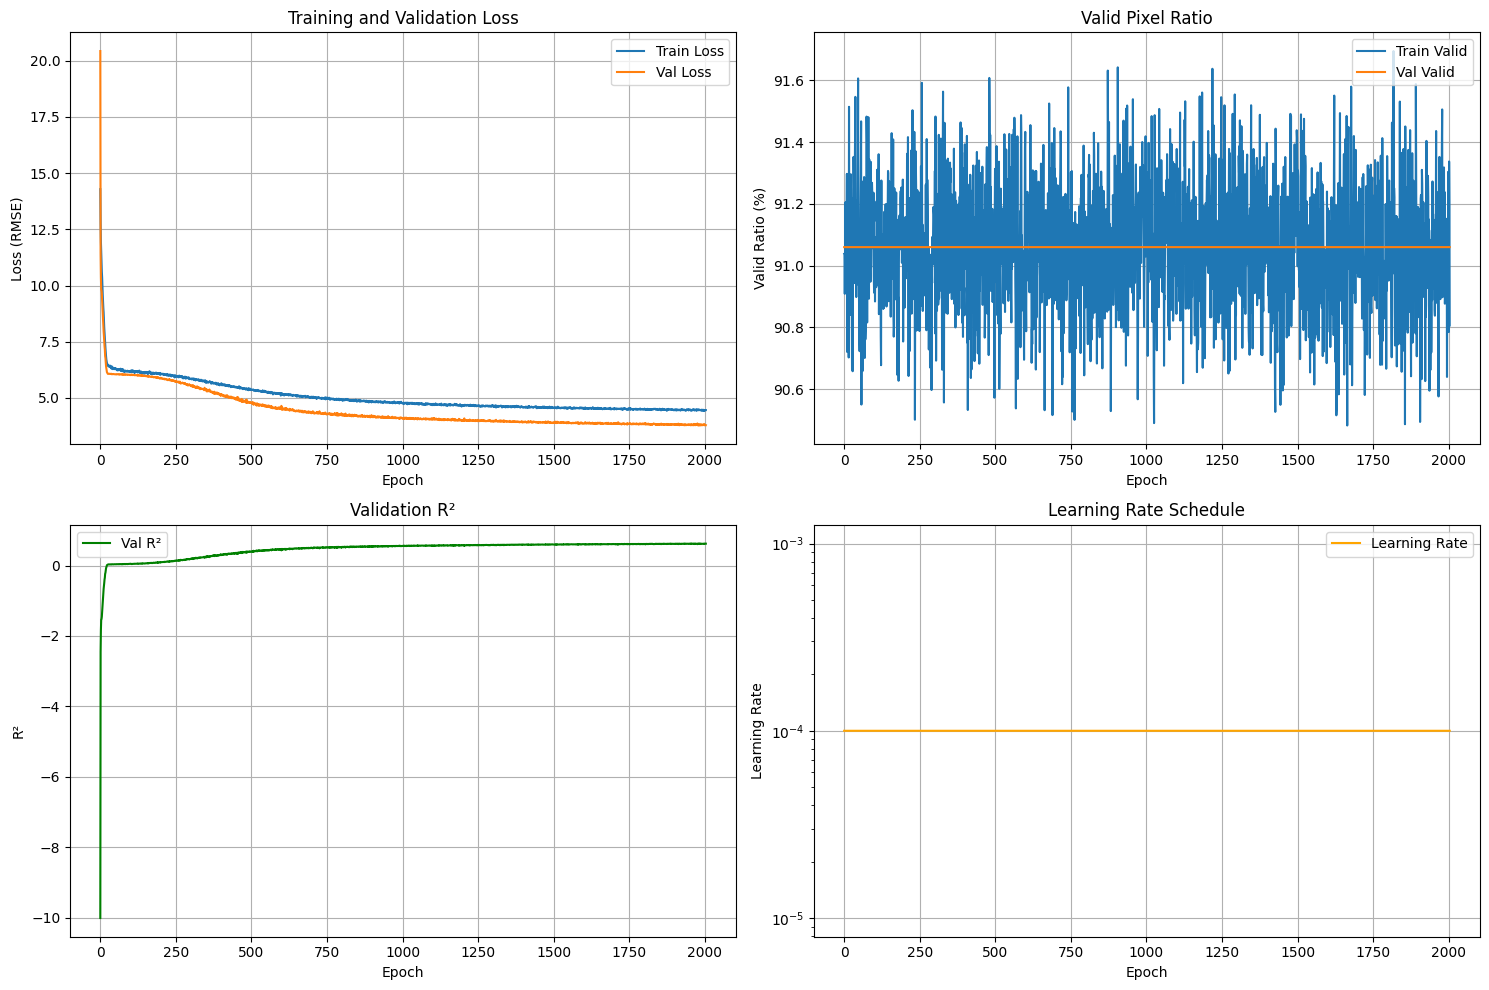

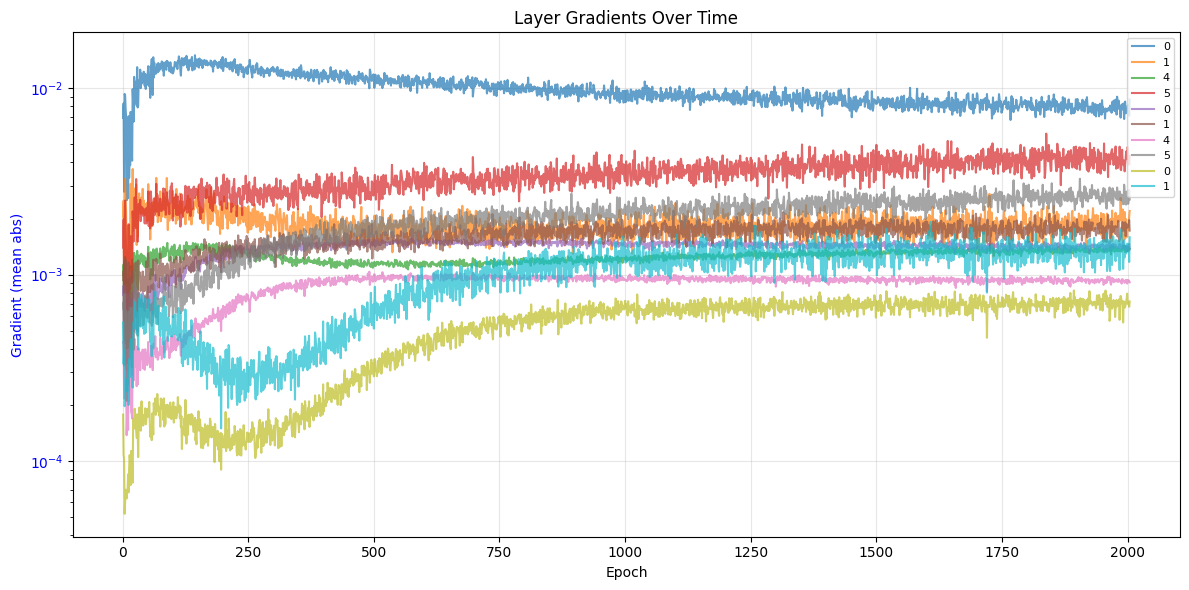

In [32]:
plot_training_history(history)
plot_gradient_history(history)

### Test

In [33]:
print(f"\nBest Validation Results:")
print(f"  R²: {best_val_r2:.4f}")
print(f"  Loss: {best_val_loss:.4f}")

# Load best model and evaluate on test set
print("\nLoading best model for test evaluation...")
checkpoint = torch.load('best_regression_model.pth', weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded model from epoch {checkpoint['epoch']+1}")
print(f"  Validation R²: {checkpoint['val_r2']:.4f}")
print(f"  Validation Loss: {checkpoint['val_loss']:.4f}\n")

test_loss, test_r2, test_valid_ratio = evaluate_regression(
    model, test_loader, criterion, device
)

print(f"\nTest Results:")
print(f"  Loss (RMSE): {test_loss:.4f}")
print(f"  R²: {test_r2:.4f}")
print(f"  Valid Pixel Ratio: {test_valid_ratio*100:.1f}%")


Best Validation Results:
  R²: 0.6242
  Loss: 3.7770

Loading best model for test evaluation...
Loaded model from epoch 1980
  Validation R²: 0.6242
  Validation Loss: 3.7770



Evaluating: 100%|██████████| 40/40 [00:00<00:00, 61.57it/s, RMSE=6.7501, R²=-0.300, Valid=98.4%]


Test Results:
  Loss (RMSE): 6.6055
  R²: -0.3487
  Valid Pixel Ratio: 91.0%


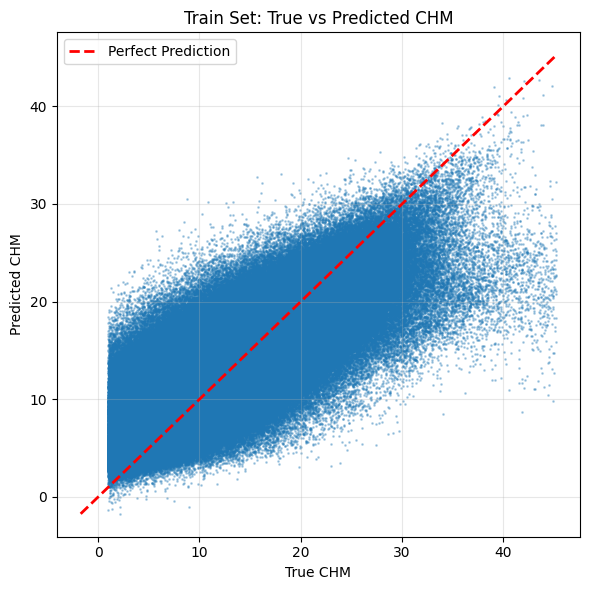


Train Set stats:
  True: [1.00, 45.21]
  Pred: [-1.72, 42.84]
  STD: 4.83
  Mean: 14.20


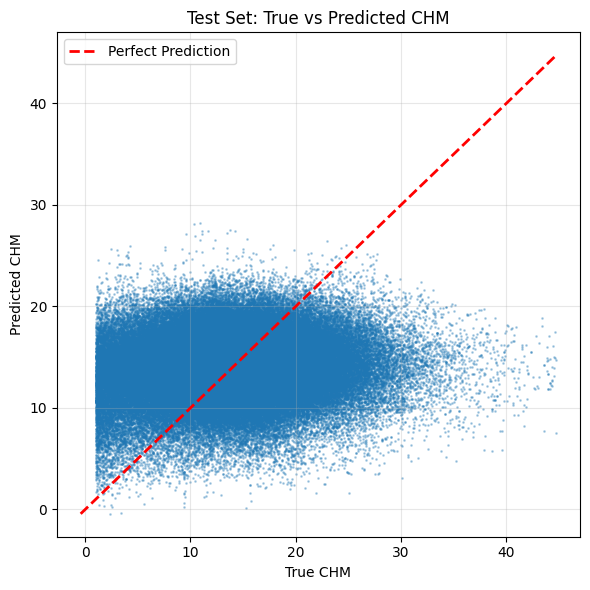


Test Set stats:
  True: [1.00, 44.74]
  Pred: [-0.43, 28.26]
  STD: 3.05
  Mean: 14.01


/tmp/ipython-input-1579963237.py:73: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  viridis_nan = cm.get_cmap('viridis').copy()


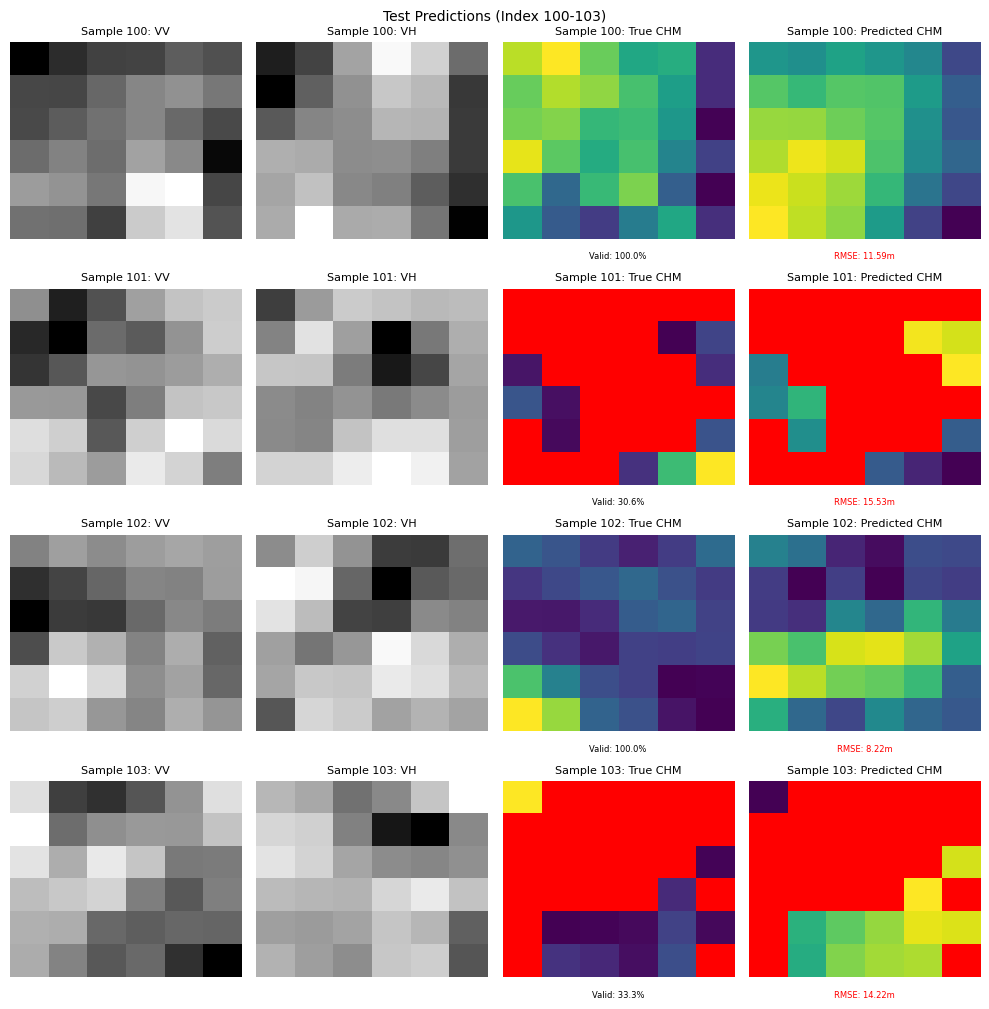

In [34]:


"""### Visualization Functions"""

def plot_scatter_prediction(model, loader, device, loader_name="Train"):
    """Plot scatter plot of true vs predicted CHM"""
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for inputs, targets in tqdm(loader, desc=f"Collecting {loader_name} predictions"):
            inputs, targets = inputs.to(device), targets.to(device)
            preds = model(inputs)

            mask = create_mask(preds, targets)
            y_true.append(targets[mask].cpu().numpy())
            y_pred.append(preds[mask].cpu().numpy())

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)

    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, s=1, alpha=0.3)
    plt.xlabel("True CHM", fontsize=10)
    plt.ylabel("Predicted CHM", fontsize=10)
    plt.title(f"{loader_name} Set: True vs Predicted CHM", fontsize=12)

    min_val, max_val = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'scatter_plot_{loader_name.lower()}.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\n{loader_name} Set stats:")
    print(f"  True: [{y_true.min():.2f}, {y_true.max():.2f}]")
    print(f"  Pred: [{y_pred.min():.2f}, {y_pred.max():.2f}]")
    print(f"  STD: {y_pred.std():.2f}")
    print(f"  Mean: {y_pred.mean():.2f}")

    return y_true, y_pred

def visualize_test_samples(model, test_loader, device, num_samples=4, start_index=0):
    """Visualize test samples with predictions"""
    model.eval()
    samples = []

    with torch.no_grad():
        for i, (inputs, targets) in enumerate(test_loader):
            batch_start = i * test_loader.batch_size
            batch_end = batch_start + inputs.shape[0]

            if batch_end <= start_index or batch_start >= start_index + num_samples:
                continue

            inputs, targets = inputs.to(device), targets.to(device)
            preds = model(inputs)

            for j in range(inputs.shape[0]):
                idx = batch_start + j
                if start_index <= idx < start_index + num_samples:
                    samples.append({
                        'idx': idx,
                        'input': inputs[j].cpu().numpy(),  # (2, H, W) - VV, VH
                        'target': targets[j, 0].cpu().numpy(),
                        'pred': preds[j, 0].cpu().numpy()
                    })

            if len(samples) >= num_samples:
                break

    viridis_nan = cm.get_cmap('viridis').copy()
    viridis_nan.set_bad(color='red')

    fig, axes = plt.subplots(num_samples, 4, figsize=(10, 2.5*num_samples))
    if num_samples == 1:
        axes = axes.reshape(1, -1)

    for i, s in enumerate(samples):
        # Input bands: VV, VH
        for j, name in enumerate(['VV', 'VH']):
            axes[i, j].imshow(s['input'][j], cmap='gray', aspect='auto')
            axes[i, j].set_title(f"Sample {s['idx']}: {name}", fontsize=8)
            axes[i, j].axis('off')

        # Target
        valid_mask = ~np.isnan(s['target'])
        valid_pct = valid_mask.sum() / valid_mask.size * 100
        axes[i, 2].imshow(s['target'], cmap=viridis_nan, aspect='auto')
        axes[i, 2].set_title(f"Sample {s['idx']}: True CHM", fontsize=8)
        axes[i, 2].text(0.5, -0.1, f"Valid: {valid_pct:.1f}%",
                       transform=axes[i, 2].transAxes, ha='center', fontsize=6)
        axes[i, 2].axis('off')

        # Prediction
        pred_masked = s['pred'].copy()
        pred_masked[~valid_mask] = np.nan
        axes[i, 3].imshow(pred_masked, cmap=viridis_nan, aspect='auto')
        axes[i, 3].set_title(f"Sample {s['idx']}: Predicted CHM", fontsize=8)

        if valid_mask.any():
            rmse = np.sqrt(np.mean((s['target'][valid_mask] - s['pred'][valid_mask]) ** 2))
            axes[i, 3].text(0.5, -0.1, f"RMSE: {rmse:.2f}m",
                           transform=axes[i, 3].transAxes, ha='center', fontsize=6, color='red')
        axes[i, 3].axis('off')

    plt.tight_layout()
    plt.suptitle(f'Test Predictions (Index {start_index}-{start_index+num_samples-1})',
                 fontsize=10, y=1.002)
    plt.savefig('test_samples_visualization.png', dpi=300, bbox_inches='tight')
    plt.show()

    return samples

# Generate visualizations
y_true_train, y_pred_train = plot_scatter_prediction(model, train_loader, device, "Train")
y_true_test, y_pred_test = plot_scatter_prediction(model, test_loader, device, "Test")
_ = visualize_test_samples(model, test_loader, device, num_samples=4, start_index=100)



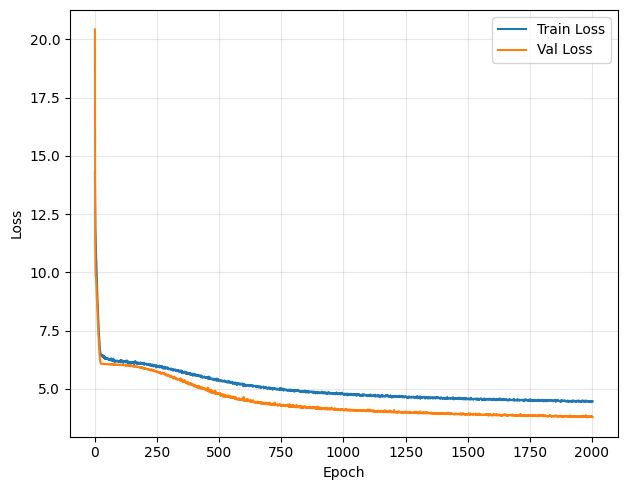

KeyError: 3.7941536500420368

In [37]:
# 你应该同时绘制这个图
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

# 找到验证损失最小的 epoch
best_epoch = np.argmin(history[val_loss])
print(f"最佳 Epoch: {best_epoch}")